# Rotation Curves

Galaxy rotation curves are the plot of the rotational velocities of stars within the galaxy against their radial distance from the galactic centre. The velocity of stars is dependent on the gravitational forces experienced by the stars, and therefore is dependent on the mass distribution within the galaxy. By plotting the rotation curve of the galaxy Andromeda, we can compare the observed rotation curve to the rotation curve predicted by Newtonian mechanics, which is a crucial step for validating Newtonian mechanics in describing galactic behaviour.

* Initialize a Miyamoto-Nagai disk potential and plot its rotation curve
  
  $$ \Phi(R,z) = -\frac{\mathrm{amp}}{\sqrt{R^2+(a+\sqrt{z^2+b^2})^2}} $$

Where,
* amp (float or Quantity, optional) – Amplitude to be applied to the potential, the total mass (default: 1); can be a Quantity with units of mass or Gxmass.
* a (float or Quantity, optional) – Scale length.
* b (float or Quantity, optional) – Scale height.
* normalize (bool or float, optional) – If True, normalize such that vc(1.,0.)=1., or, if given as a number, such that the force is this fraction of the force necessary to make vc(1.,0.)=1.
* ro (float, optional) – Distance scale for translation into internal units (default from configuration file).
* vo (float, optional) – Velocity scale for translation into internal units (default from configuration file).

Related References\
[1] Miyamoto, M., & Nagai, R. (1975). Three-dimensional models for the distribution of mass in galaxies. Publications of the Astronomical Society of Japan, 27(4), 533-543. ADS: https://ui.adsabs.harvard.edu/abs/1975PASJ…27..533M/abstract

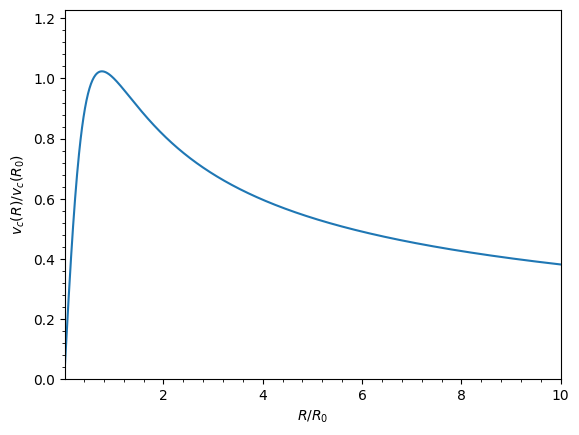

In [15]:
from galpy.potential import MiyamotoNagaiPotential
mp= MiyamotoNagaiPotential(a=0.5,b=0.0375,normalize=1.)
mp.plotRotcurve(Rrange=[0.01,10.],grid=1001);

The normalize=1. option normalizes the potential such that the radial force is a fraction normalize=1. of the radial force necessary to make the circular velocity 1 at R=1. 

Similarly we can do for other potentials.

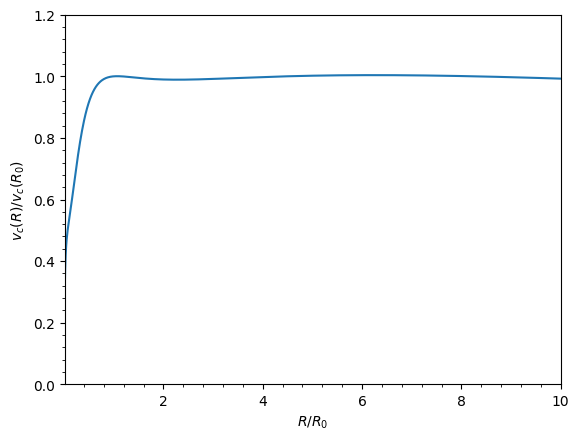

In [16]:
from galpy.potential import NFWPotential, HernquistPotential
mp= MiyamotoNagaiPotential(a=0.5,b=0.0375,normalize=.6)
np= NFWPotential(a=4.5,normalize=.35)
hp= HernquistPotential(a=0.6/8,normalize=0.05)
# hp.plotRotcurve(Rrange=[0.01,10.],grid=1001,yrange=[0.,1.2]);
(hp+mp+np).plotRotcurve(Rrange=[0.01,10.],grid=1001,yrange=[0.,1.2]);

Note that the normalize values add up to 1. such that the circular velocity will be 1 at R=1. Potentials can be combined into a composite potential by adding them up hp+mp+np. The resulting rotation curve is approximately flat. To show the rotation curves of the three components...

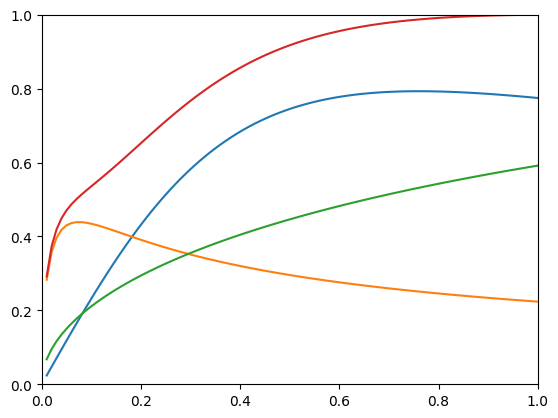

In [17]:
mp.plotRotcurve(Rrange=[0.01,10.],grid=1001,overplot=True)
hp.plotRotcurve(Rrange=[0.01,10.],grid=1001,overplot=True)
np.plotRotcurve(Rrange=[0.01,10.],grid=1001,overplot=True)
(hp+mp+np).plotRotcurve(Rrange=[0.01,10.],grid=1001, overplot=True);

## For milky-way like potential

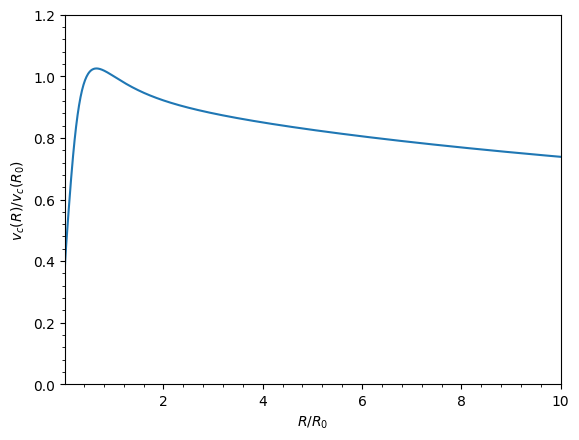

In [18]:
from galpy.potential import MWPotential2014
mw = MWPotential2014
mw.plotRotcurve(Rrange=[0.01,10.],grid=1001, yrange=[0.,1.2]);

## Units Conversion

Galpy will work most robustly when using these natural units. When using galpy to model a real galaxy with, say, a circular velocity of 220 km/s at R=8 kpc, all of the velocities should be scaled as v= V/[220 km/s] and all of the positions should be scaled as x = X/[8 kpc] when using galpy’s natural units.

In natural units the orbital time of a circular orbit at R = 1 is 2⁢𝜋; in physical units this corresponds to

In [19]:
from galpy.util import conversion
import numpy as np
print(2.*np.pi*conversion.time_in_Gyr(220.,8.)) #220 is circular veloctiy and 8 is distance from centre

0.22340544439051707


which means 223 Myr. conversion further has functions to convert densities, masses, surface densities, and frequencies to physical units (actions are considered to be too obvious to be included); see here for a full list. As a final example, the local dark matter density in the Milky-Way-like potential is given by

In [20]:
print(MWPotential2014[2].dens(1.,0.)*conversion.dens_in_msolpc3(220.,8.))

0.0075438553390854805


In [21]:
print(MWPotential2014[2].dens(1.,0.)*conversion.dens_in_gevcc(220.,8.))

0.2864037094626491


or about 0.0075 $M_\odot$ pc$^{−3}$ $\approx$ 0.3 GeVcm$^{−3}$, in line with current measurements

# Orbits

We can also integrate orbits in all galpy potentials. Going back to a simple Miyamoto-Nagai potential, we initialize an orbit as follows

In [22]:
from galpy.orbit import Orbit
mp = MiyamotoNagaiPotential(a=0.5, b = 0.0375, amp=1.,normalize=1.)
o = Orbit ([1.,0.1,1.1,0.,0.1]) #[R, vR, vT, z, vZ]

Since we are using five-d initial conditions we assume we are dealing with axisymmetric potential in which we do not wish to track the azimuth. We then integrate the orbit for a set of time ts

In [23]:
ts = np.linspace(0,100,10000)
o.integrate(ts,mp)

Plotting Orbit

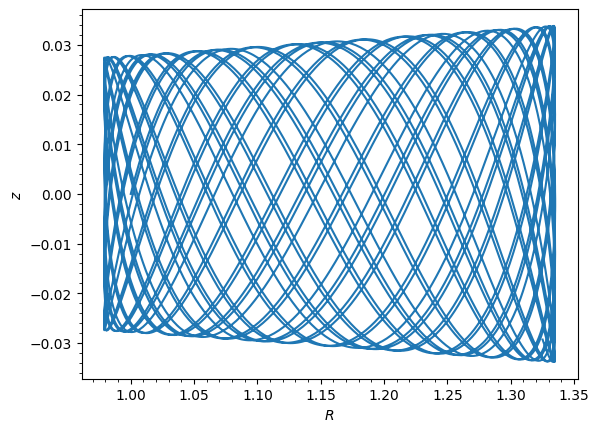

In [25]:
o.plot();

Plotting energy

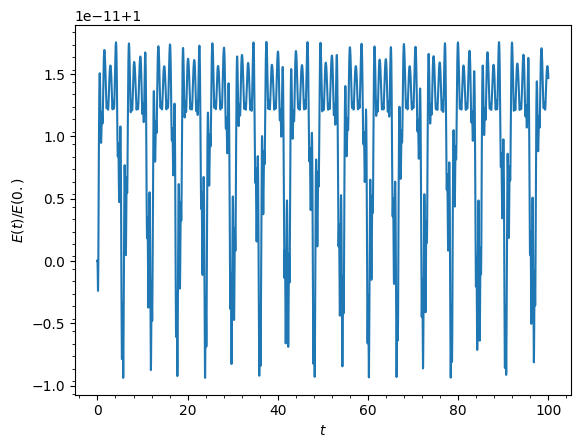

In [28]:
o.plotE(normed=True);

Using fast intergration solver

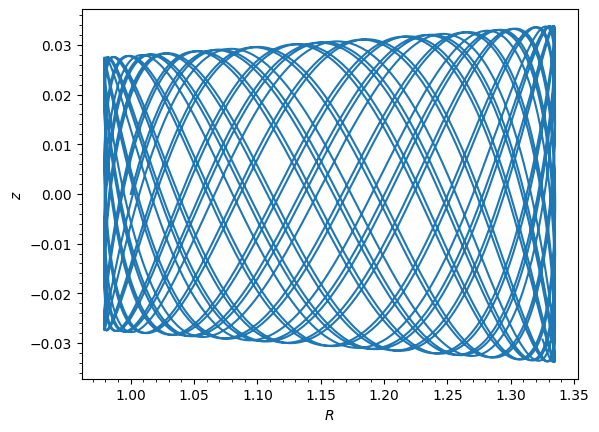

In [29]:
o.integrate(ts,mp,method='dopr54_c')
o.plot();

Using multiple potentials

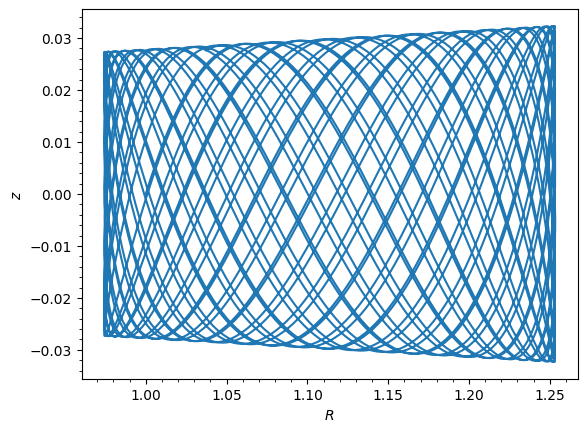

In [38]:
o.integrate(ts,mp+hp)
o.plot();

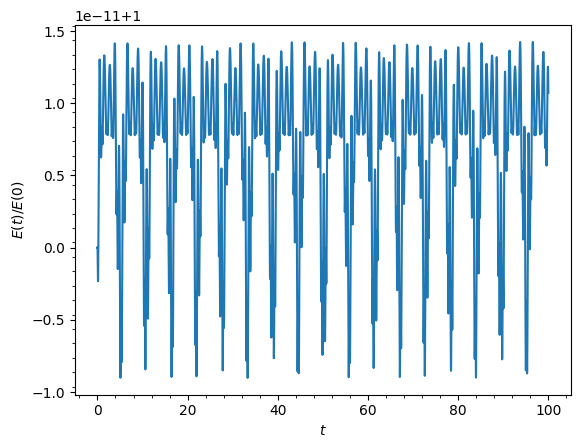

In [43]:
o.plotE(xlabel=r'$t$', ylabel=r'$E(t)/E(0)$', normed=True);

## Escape Velocity

Escape velocity curve for Miyamoto-Nagai disk 

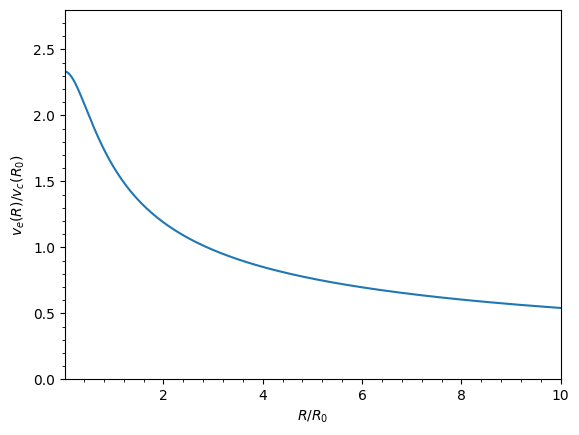

In [44]:
mp.plotEscapecurve(Rrange=[0.01,10.], grid=1001);

or for combinations

For milky-way like potential

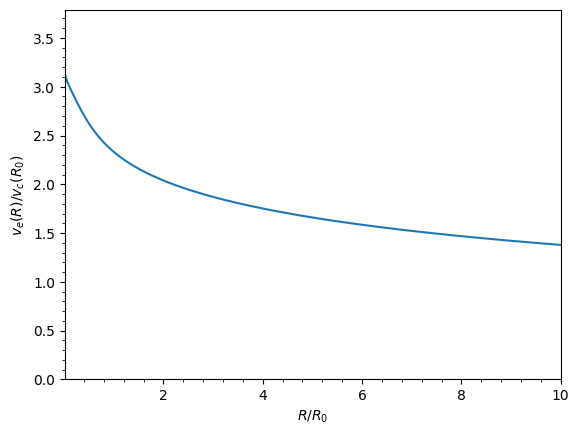

In [47]:
MWPotential2014.plotEscapecurve(Rrange=[0.01,10.],grid=1001);

at solar radius

In [51]:
print(MWPotential2014.vesc(1.))

2.3316389848832784


for a local circular velocity of 220 km/s

In [53]:
print(MWPotential2014.vesc(1.)*220.)
# 512.96057667432126

512.9605766743213
